# LightGBMによる楽曲人気度予測：改良版

このNotebookでは、簡素なLightGBM分析を保ちながら、次の4点を追加する。

1. `key`、`mode`、`time_signature`、`explicit`を含む全数値特徴量を使用する  
2. `artists`から`main_artist`と`artist_count`を作る  
3. 5-fold交差検証で性能を安定して評価する  
4. 予測値を0〜100に制限し、制限前後のMSEを比較する  

## 分析の流れ

1. データを読み込む  
2. 特徴量を準備する  
3. 4種類の特徴量構成を5-fold交差検証で比較する  
4. 最良の特徴量構成を選ぶ  
5. 真値と予測値を散布図で確認する  
6. 全訓練データで学習し、テストデータを予測する  


## 1. ライブラリの読み込み

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from google.colab import drive
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

pd.set_option("display.max_columns", None)

print("LightGBM version:", lgb.__version__)


LightGBM version: 4.6.0


## 2. Google Driveをマウントしてデータを読み込む

`NOTEBOOK_DIR`は、このNotebookを保存しているフォルダに合わせて変更する。


In [2]:
# 1. Google Driveをマウント
drive.mount("/content/drive")

# 2. Notebookが置かれているフォルダを指定
NOTEBOOK_DIR = (
    "/content/drive/My Drive/Colab Notebooks/"
    "情報理工実験/データサイエンス/Lecture02"
)

# 3. 作業フォルダを変更
os.chdir(NOTEBOOK_DIR)
print("現在の作業フォルダ:", os.getcwd())

# 4. データを読み込む
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
submission_example = pd.read_csv("data/y_pred_example.csv")

print("データの読み込みが完了しました。")
print("train:", train.shape)
print("test :", test.shape)


Mounted at /content/drive
現在の作業フォルダ: /content/drive/My Drive/Colab Notebooks/情報理工実験/データサイエンス/Lecture02
データの読み込みが完了しました。
train: (79800, 21)
test : (34200, 20)


## 3. 特徴量を追加する

`artists`の先頭アーティストを`main_artist`とする。  
また、`;`で区切られたアーティスト数を`artist_count`として追加する。


In [3]:
for df in [train, test]:
    # 欠損値を空文字に置き換える
    artists_text = df["artists"].fillna("")

    # 先頭のアーティスト名
    df["main_artist"] = (
        artists_text.str.split(";").str[0].str.strip()
        .replace("", "Unknown")
    )

    # 参加アーティスト数
    df["artist_count"] = np.where(
        artists_text.eq(""),
        0,
        artists_text.str.count(";") + 1
    )

    # explicitを0または1に変換
    df["explicit"] = df["explicit"].astype(int)

display(train[["artists", "main_artist", "artist_count"]].head())


,artists,main_artist,artist_count
0,Olivier Abeille,Olivier Abeille,1
1,Nonpoint,Nonpoint,1
2,Porter Robinson;Urban Cone,Porter Robinson,2
3,Rosana,Rosana,1
4,The Everly Brothers,The Everly Brothers,1


## 4. カテゴリ特徴量を準備する

訓練データとテストデータで同じカテゴリ定義を使用する。


In [4]:
categorical_features = ["track_genre", "main_artist"]

for col in categorical_features:
    all_values = pd.concat([train[col], test[col]], axis=0)
    category_type = pd.CategoricalDtype(
        categories=all_values.dropna().unique()
    )

    train[col] = train[col].astype(category_type)
    test[col] = test[col].astype(category_type)

print("カテゴリ特徴量の準備が完了しました。")


カテゴリ特徴量の準備が完了しました。


## 5. 4種類の特徴量構成を定義する

今回は、すべての数値特徴量を使用する。  
そこへジャンルとアーティスト情報を段階的に追加する。


In [5]:
target = "popularity"

numeric_features = [
    "duration_ms",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
    "explicit"
]

experiments = {
    "1. Numeric only":
        numeric_features,

    "2. Numeric + Genre":
        numeric_features + ["track_genre"],

    "3. Numeric + Artist":
        numeric_features + ["main_artist", "artist_count"],

    "4. Numeric + Genre + Artist":
        numeric_features
        + ["track_genre", "main_artist", "artist_count"]
}

for name, features in experiments.items():
    print(name, ":", len(features), "features")


1. Numeric only : 14 features
2. Numeric + Genre : 15 features
3. Numeric + Artist : 16 features
4. Numeric + Genre + Artist : 17 features


## 6. 5-fold交差検証を行う関数

訓練データを5分割し、4つを学習、1つを検証に使用する。  
この処理を5回繰り返し、平均MSEを求める。

予測値は、そのままの場合と0〜100に制限した場合の両方を評価する。


In [6]:
def cross_validate_lightgbm(features):
    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_results = []
    oof_pred = np.zeros(len(train))
    best_iterations = []

    X = train[features]
    y = train[target]

    for fold, (fit_index, valid_index) in enumerate(kf.split(X), start=1):
        X_fit = X.iloc[fit_index]
        X_valid = X.iloc[valid_index]
        y_fit = y.iloc[fit_index]
        y_valid = y.iloc[valid_index]

        model = lgb.LGBMRegressor(
            objective="regression",
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            verbosity=-1
        )

        model.fit(
            X_fit,
            y_fit,
            eval_set=[(X_valid, y_valid)],
            eval_metric="mse",
            categorical_feature=[
                col for col in features
                if col in categorical_features
            ],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(0)
            ]
        )

        pred = model.predict(
            X_valid,
            num_iteration=model.best_iteration_
        )
        clipped_pred = np.clip(pred, 0, 100)

        oof_pred[valid_index] = clipped_pred
        best_iterations.append(model.best_iteration_)

        fold_results.append({
            "fold": fold,
            "MSE": mean_squared_error(y_valid, pred),
            "clipped_MSE": mean_squared_error(
                y_valid,
                clipped_pred
            )
        })

    fold_results = pd.DataFrame(fold_results)

    return {
        "MSE": fold_results["MSE"].mean(),
        "clipped_MSE": fold_results["clipped_MSE"].mean(),
        "best_iteration": int(np.mean(best_iterations)),
        "oof_pred": oof_pred,
        "fold_results": fold_results
    }


## 7. 4つの実験を比較する

各実験について5-fold交差検証を行い、平均MSEを比較する。


In [7]:
results = []
cv_outputs = {}

for experiment_name, features in experiments.items():
    output = cross_validate_lightgbm(features)
    cv_outputs[experiment_name] = output

    results.append({
        "experiment": experiment_name,
        "number_of_features": len(features),
        "MSE": output["MSE"],
        "clipped_MSE": output["clipped_MSE"],
        "best_iteration": output["best_iteration"]
    })

    print(
        f"{experiment_name}: "
        f"MSE={output['MSE']:.4f}, "
        f"clipped_MSE={output['clipped_MSE']:.4f}"
    )

results_df = (
    pd.DataFrame(results)
    .sort_values("clipped_MSE")
    .reset_index(drop=True)
)

display(results_df)


1. Numeric only: MSE=383.5815, clipped_MSE=383.5804
2. Numeric + Genre: MSE=300.8640, clipped_MSE=300.8564
3. Numeric + Artist: MSE=279.3941, clipped_MSE=279.3371
4. Numeric + Genre + Artist: MSE=238.6902, clipped_MSE=238.4544


,experiment,number_of_features,MSE,clipped_MSE,best_iteration
0,4. Numeric + Genre + Artist,17,238.690231,238.454403,500
1,3. Numeric + Artist,16,279.394088,279.337079,500
2,2. Numeric + Genre,15,300.864015,300.856371,500
3,1. Numeric only,14,383.581517,383.580390,500


## 8. 予測値の範囲制限による変化を確認する

`clipped_MSE`が`MSE`より小さければ、0〜100への制限によって誤差が改善している。


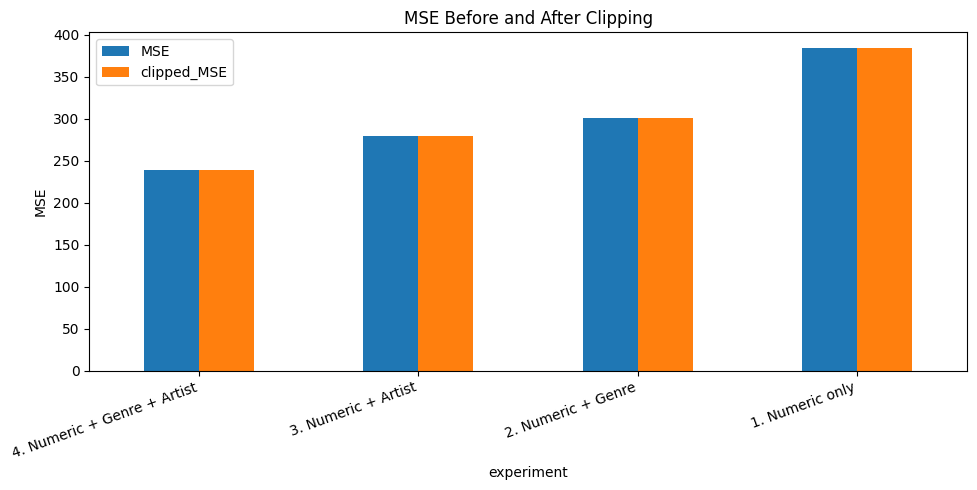

In [8]:
comparison_df = results_df[
    ["experiment", "MSE", "clipped_MSE"]
].set_index("experiment")

comparison_df.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("MSE")
plt.title("MSE Before and After Clipping")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 9. 最良の特徴量構成を確認する

0〜100に制限した後の平均MSEが最小の実験を選ぶ。


In [9]:
best_experiment = results_df.loc[0, "experiment"]
best_features = experiments[best_experiment]
best_output = cv_outputs[best_experiment]

print("Best experiment:", best_experiment)
print("CV MSE:", results_df.loc[0, "clipped_MSE"])
print("Number of features:", len(best_features))


Best experiment: 4. Numeric + Genre + Artist
CV MSE: 238.45440345364767
Number of features: 17


## 10. 真値と予測値を散布図で比較する

5-fold交差検証によって得た各データの予測値を使用する。  
点が破線に近いほど、真値と予測値がよく一致している。


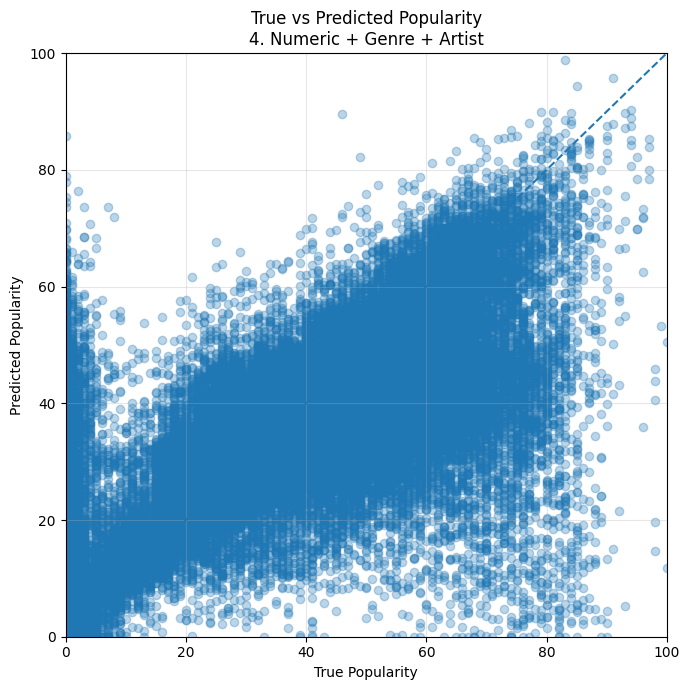

In [10]:
y_true = train[target]
y_oof_pred = best_output["oof_pred"]

plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_oof_pred, alpha=0.3)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("True Popularity")
plt.ylabel("Predicted Popularity")
plt.title(
    f"True vs Predicted Popularity\n{best_experiment}"
)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. 最良の特徴量構成で全訓練データを学習する

交差検証で得られた平均的な学習回数を使用する。


In [11]:
best_n_estimators = int(
    results_df.loc[0, "best_iteration"]
)

final_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=best_n_estimators,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

final_model.fit(
    train[best_features],
    train[target],
    categorical_feature=[
        col for col in best_features
        if col in categorical_features
    ]
)

test_pred = final_model.predict(test[best_features])

# popularityの範囲に制限
test_pred = np.clip(test_pred, 0, 100)

print("最終モデルの学習と予測が完了しました。")
print("使用した実験:", best_experiment)
print("木の本数:", best_n_estimators)


最終モデルの学習と予測が完了しました。
使用した実験: 4. Numeric + Genre + Artist
木の本数: 500


## 12. 特徴量重要度を確認する

最終モデルが分岐に多く使用した特徴量を確認する。


,feature,importance
15,main_artist,4050
14,track_genre,1932
9,liveness,970
6,speechiness,937
4,loudness,904
10,valence,901
0,duration_ms,880
1,danceability,807
7,acousticness,782
11,tempo,761


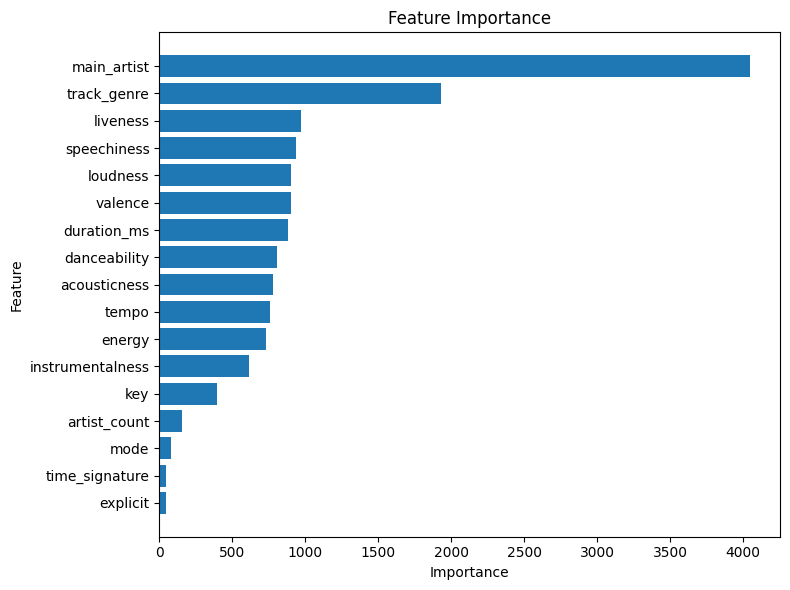

In [12]:
importance_df = pd.DataFrame({
    "feature": best_features,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 6))
plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()


## 13. 提出用CSVを作成する

`y_pred_example.csv`の形式を保ったまま、予測値を保存する。


In [16]:
# test.csvに対する予測値だけを、1列で保存する
pd.Series(test_pred).to_csv(
    "submission/lightgbm_improved_submission.csv",
    index=False,
    header=False
)

print("保存先: lightgbm_improved_submission.csv")


OSError: Cannot save file into a non-existent directory: '/submission'

## 14. まとめ

このNotebookでは、簡素なLightGBM分析に次の改善を加えた。

- すべての数値特徴量を使用した
- `main_artist`と`artist_count`を追加した
- 5-fold交差検証で安定した評価を行った
- 予測値を0〜100に制限した
- 交差検証による真値と予測値を散布図で確認した

高度なハイパーパラメータ探索は行わず、特徴量と評価方法の改善に限定している。
